<a href="https://colab.research.google.com/github/programminghistorian/jekyll/blob/gh-pages/assets/understanding-creating-word-embeddings/understanding-creating-word-embeddings.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Preparing Your Corpus

In [2]:
%pip install gensim

Note: you may need to restart the kernel to use updated packages.


In [2]:
# A good practice in programming is to place your import statements at the top of your code, and to keep them together

import re                                   # for regular expressions
import os                                   # to look up operating system-based info
import string                               # to do fancy things with strings
import glob                                 # to locate a specific file type
from pathlib import Path                    # to access files in other directories
import gensim                               # to access Word2Vec
from gensim.models import Word2Vec          # to access Gensim's flavor of Word2Vec
import pandas as pd                         # to sort and organize data
import random

In [3]:
data = ''

with open("mansfield.txt", mode='r', encoding='utf-8-sig') as file:
        data = [p.split("\n")[0] for p in file.read().split('\n\n')]
        file.close()

print(f"{len(data)} paragraphs looaded.")

1792 paragraphs looaded.


In [4]:
import nltk

def clean_text(text):

    # Cleans the given text using regular expressions to split and lower-cased versions to create
    # a list of tokens for each text.
    # The function accepts a list of texts and returns a list of of lists of tokens

    # lower case
    tokens = re.split(
        r"[\s\n.]+",
        text.replace("—", " ")
        .replace("’", "")
        .replace("‘", " ")
        .replace("“", "")
        .replace("”", ""),
    )
    tokens = [t[0] if t[1] == "NNP" else t[0].lower() for t in nltk.pos_tag(tokens)]

    # remove punctuation using regular expressions
    # this line of code locates the punctuation within the given text and compiles that punctuation into a single variable
    re_punc = re.compile('[%s]' % re.escape(string.punctuation))
    # this line of code substitutes the punctuation we just compiled with nothing ''
    tokens = [re_punc.sub('', token) for token in tokens]

    # only include tokens that aren't numbers
    tokens = [token for token in tokens if token.isalnum()]
    return tokens

In [5]:
# clean text from folder of text files, stored in the data variable
data_clean = []
for x in data:
    data_clean.append(clean_text(x))

In [552]:
# Check that the length of data and the length of data_clean are the same. Both numbers printed should be the same

print(len(data))
print(len(data_clean))

1792
1792


In [553]:
# check that the first item in data and the first item in data_clean are the same.
# both print statements should print the same word, with the data cleaning function applied in the second one

print(data[0].split()[0])
print(data_clean[0][0])

MANSFIELD
MANSFIELD


In [554]:
# check that the last item in data_clean and the last item in data are the same
# both print statements should print the same word, with the data cleaning function applied in the second one

print(data[0].split()[-1])
print(data_clean[0][-1])

PARK
PARK


In [6]:
tokens = re.split(r'[ \n]+', data[0])
cleaned_tokens = data_clean[0]
diff = [
    f"before: \"{token}\" - after: \"{cleaned_tokens[n]}\""
    for n, token in enumerate(tokens)
    if token != cleaned_tokens[n]
]
print("\n".join(diff))

In [7]:
total_tokens = 0
modified_tokens = 0
for n, text in enumerate(data):
    tokens = [
        i
        for i in re.split(
            r"[\s\n.\d°”“]+",
            text.replace("‘", " ‘").replace("—", " ").replace(".’", "."),
        )
        if i.translate(str.maketrans("", "", string.punctuation)) != ""
    ]
    cleaned_text = data_clean[n]
    total_tokens += len(tokens)

    # Debuging code
    """
    if len(tokens) != len(cleaned_text):
        print(tokens[-1], cleaned_text[-1])
        for x, token in enumerate(tokens):
            if token != cleaned_text[x]:
                print(n, x, tokens[x-1:x+2], cleaned_text[x]) """

    modified_tokens += len([t for i, t in enumerate(tokens) if t != cleaned_text[i]])

print(f'{modified_tokens*100/total_tokens:.2f}% of the tokens were modified')

15.07% of the tokens were modified


## Model Creation

In [8]:
# train the model
model = Word2Vec(sentences=data_clean, window=2, min_count=5, epochs=10, vector_size=64, sg=1)
model_low_min_count = Word2Vec(
    sentences=data_clean, window=2, min_count=1, epochs=10, vector_size=64, sg=1
)

# save the model
model.save("word2vec_mansfield.model")

In [9]:
# load the model

model = Word2Vec.load("word2vec_mansfield.model")

## Analysis ##


### Exploratory Queries

In [559]:
# set the word that we are checking for
word = "fear"

# if that word is in our vocabulary
if word in model.wv.key_to_index:

    # print a statement to let us know
    print("The word %s is in your model vocabulary" % word)

# otherwise, let us know that it isn't
else:
    print("%s is not in your model vocabulary" % word)

The word fear is in your model vocabulary


In [560]:
# returns a list with the top ten words used in similar contexts to the word "milk"
model.wv.most_similar("fear", topn=10)

[('censure', 0.9425502419471741),
 ('difficult', 0.9310970306396484),
 ('gratifying', 0.929253101348877),
 ('curiosity', 0.9285502433776855),
 ('higher', 0.9277828335762024),
 ('amuse', 0.9259118437767029),
 ('tragedy', 0.9210647940635681),
 ('concern', 0.9209417104721069),
 ('fancy', 0.9206889271736145),
 ('unequal', 0.9201551079750061)]

In [10]:
# displays the number of words in your model's vocabulary
print(len(model.wv))
print(len(model_low_min_count.wv))

2494
8328


## Dimensionality reduction with scikit


In [568]:
%pip install scikit-learn numpy seaborn

Note: you may need to restart the kernel to use updated packages.


Here we do the dimension reduction. We use the t-distributed stochastic neighbor embedding (t-SNE) algorithm.

In [570]:
from sklearn.manifold import TSNE

# Get the word vectors
word_vectors = model.wv
vocab = list(word_vectors.key_to_index)
X = word_vectors[vocab]

# do the actual dimension reduction
X_embedded = TSNE(
    n_components=2, learning_rate="auto", perplexity=40
).fit_transform(X)


Now, we'l try to get some visualisation of the word-vectors. First we'll have a look on to which extent the frequency of a word in the training corpus has an influence on that vector representation. The goal was to reproduce the results from the paper, but as we can see, the results are quite different, with the most common word (red-orange) being scattered around the periphery of the plot. A look on the paper informs us that their plot was actually obtained using Principal Component Analysis.

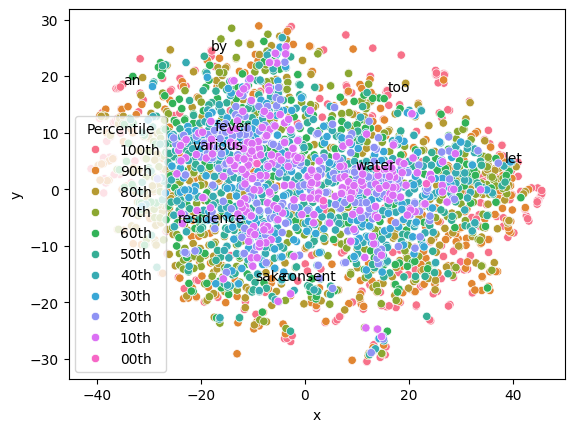

In [574]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
from numpy import random


df = pd.DataFrame(X_embedded, columns=["x", "y"])
df["word"] = vocab
df["Percentile"] = [f"{10-(i//(len(vocab)//10))}0th" for i, pos in enumerate(vocab)]

# Plot using Seaborn
sns.scatterplot(x="x", y="y", data=df, hue="Percentile")

# Annotate the points with the words
for i in range(10):
    n = random.randint(len(vocab))
    plt.annotate(df["word"][n], (df["x"][n], df["y"][n]))

plt.show()

Following a quick look at the paper, I decided to retry the operation but with two changes. First, I set the minimum count to 1, second, I used PCA for the dimensionality reduction. This time, I could get results visualy closer to the ones in the paper, although not exactly the same.

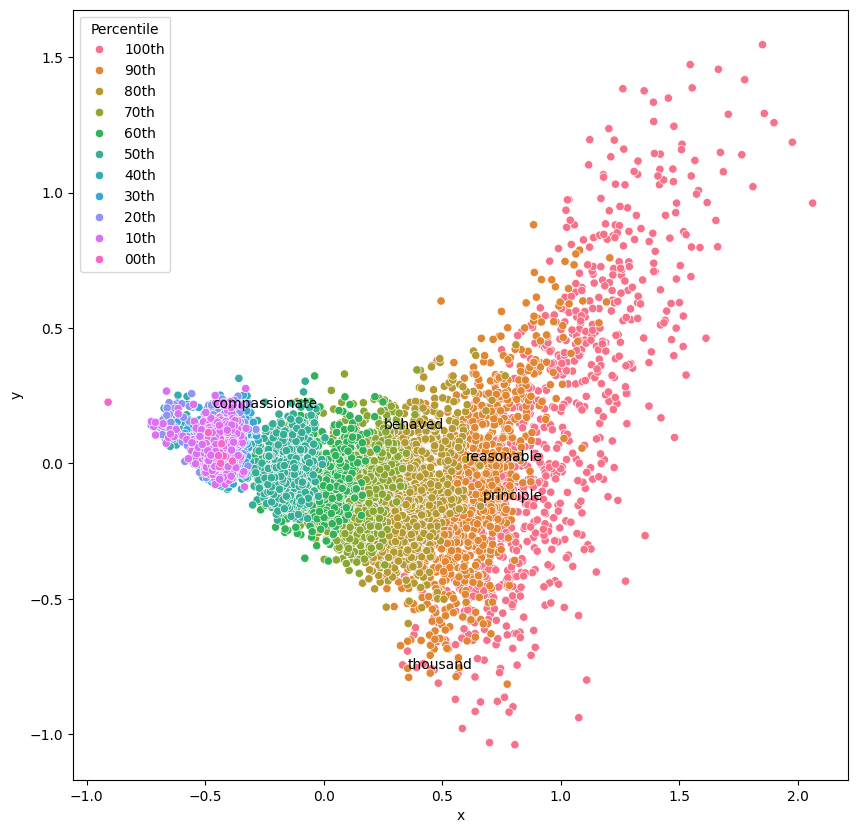

In [580]:
from sklearn.decomposition import PCA

word_vectors = model_low_min_count.wv
vocab = list(word_vectors.key_to_index)
X = word_vectors[vocab]

pca = PCA(n_components=2)
X_pca = pca.fit_transform(X)

df = pd.DataFrame(X_pca, columns=["x", "y"])
df["word"] = vocab
df["Percentile"] = [f"{10-(i//(len(vocab)//10))}0th" for i, pos in enumerate(vocab)]

plt.figure(figsize=(10, 10))
sns.scatterplot(x="x", y="y", data=df, hue="Percentile")


for i in range(5):
    n = random.randint(len(vocab))
    plt.annotate(df["word"][n], (df["x"][n], df["y"][n]))

plt.show()

In the next graph I tried to combine PCA and SNPE, going from 64 to 3 dimensions with PCA and using SNPE to gather the rest together at the end.

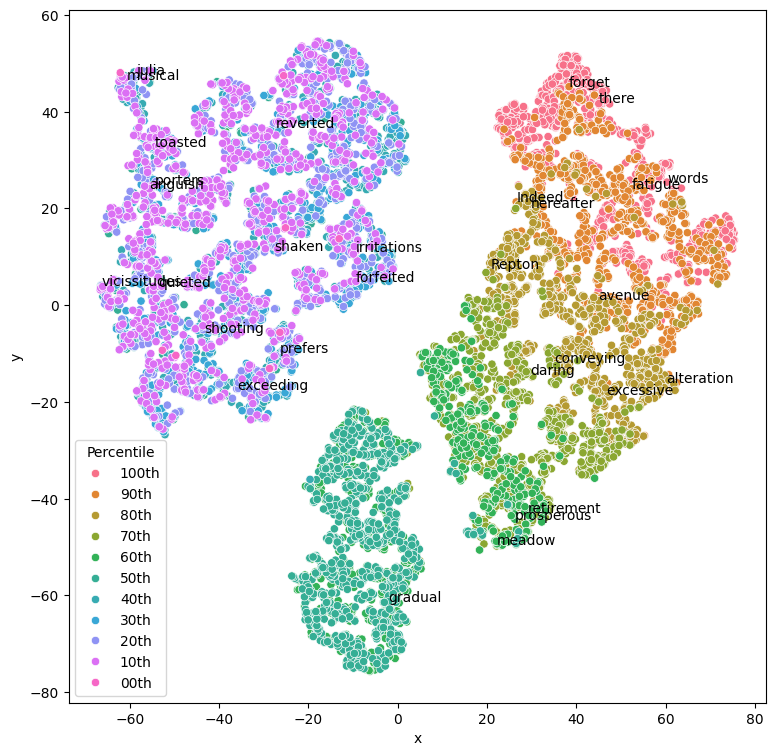

In [587]:
from sklearn.decomposition import PCA

word_vectors = model_low_min_count.wv
vocab = list(word_vectors.key_to_index)
X = word_vectors[vocab]

pca = PCA(n_components=3)
X_pca = pca.fit_transform(X)
X_embedded = TSNE(n_components=2, learning_rate="auto", perplexity=50).fit_transform(
    X_pca
)

plt.figure(figsize=(9, 9))

df = pd.DataFrame(X_embedded, columns=["x", "y"])
df["word"] = vocab
df["Percentile"] = [f"{10-(i//(len(vocab)//10))}0th" for i, pos in enumerate(vocab)]

# Plot using Seaborn
sns.scatterplot(x="x", y="y", data=df, hue="Percentile")

# Annotate random points with the words
for i in range(30):
    n = random.randint(len(vocab))
    plt.annotate(df["word"][n], (df["x"][n], df["y"][n]))

plt.show()

But something feels off concerning this graph. Training a model on scarse data may simply have as a consequence that word2vec considers the frequency of the data as one of its feature. In other word, this graph shows nothing "scientific" except that training a model on scarse data corrupts the model and make its result irrelevent. This is why we now come back to the original model for the next analysis.

In [590]:
# Get the word vectors
word_vectors = model.wv
vocab = list(word_vectors.key_to_index)
X = word_vectors[vocab]

# do the actual dimension reduction
X_embedded = TSNE(n_components=2, learning_rate="auto", perplexity=40).fit_transform(X)

X 2494


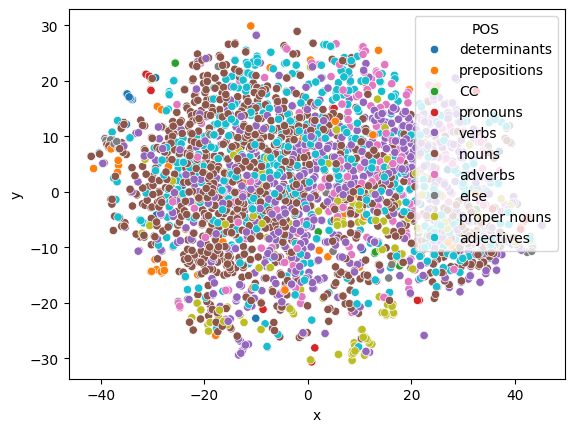

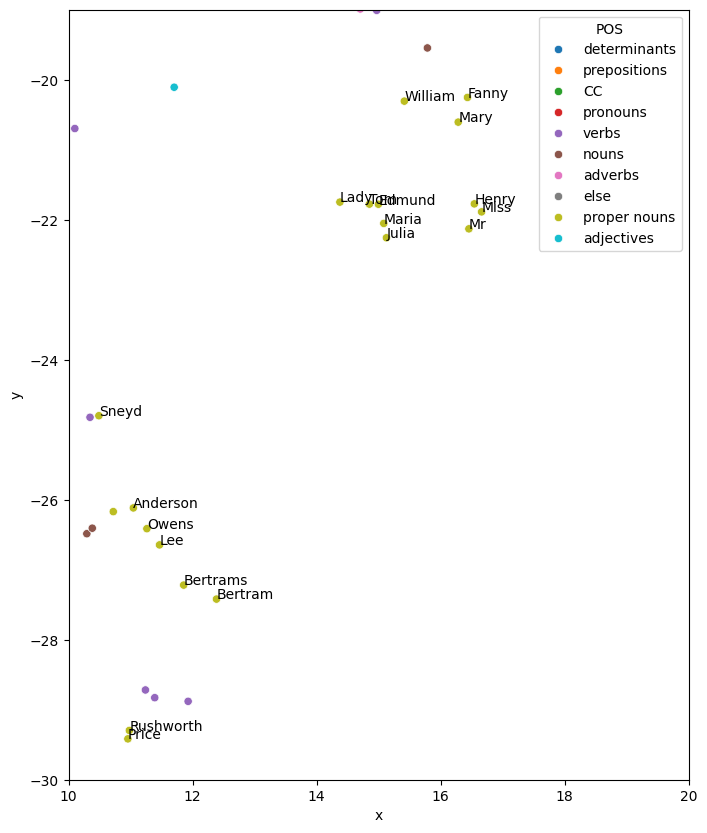

In [604]:
import seaborn as sns

print("X", len(X))

df = pd.DataFrame(X_embedded, columns=["x", "y"])
df["word"] = vocab
dic = {
    "CC": "CC",
    "CD": "else",
    "DT": "determinants",
    "EX": "else",
    "FW": "proper nouns",
    "TO": "prepositions",
    "IN": "prepositions",
    "JJ": "adjectives",
    "JJR": "adjectives",
    "JJS": "adjectives",
    "MD": "else",
    "NN": "nouns",
    "NNPS": "nouns",
    "NNS": "nouns",
    "NNP": "proper nouns",
    "PDT": "pronouns",
    "PRP": "pronouns",
    "PRP$": "pronouns",
    "RB": "adverbs",
    "RBS": "adverbs",
    "RBR": "adverbs",
    "RP": "else",
    "VB": "verbs",
    "VBD": "verbs",
    "VBG": "verbs",
    "VBN": "verbs",
    "VBP": "verbs",
    "VBZ": "verbs",
    "WDT": "determinants",
    "WP": "else",
    "WRB": "else",
    "WP$": "else",
    "UH": "else",
}

df["POS"] = [dic[pos] for word, pos in nltk.pos_tag(vocab)]

# Plot using Seaborn

sns.scatterplot(x="x", y="y", data=df, hue="POS")

plt.show()

plt.figure(figsize=(8, 10))
sns.scatterplot(x="x", y="y", data=df, hue="POS")

plt.xlim(10, 20)
plt.ylim(-30, -19)
for i in range(2400):
    if df["POS"][i] == "proper nouns":
        plt.annotate(df["word"][i], (df["x"][i], df["y"][i]))

plt.show()